# YieldSense AI — Milestone 3: Agricultural Analytics, Risk Engine & Conversational Intelligence

**Project**: YieldSense AI (Crop Yield Prediction & Agricultural Productivity Intelligence Platform)  
**Milestone**: Milestone 3 — Agricultural Analytics, Risk & Insight Scoring, AgriSense AI Chatbot, and Multi-Tenant RBAC  
**Dataset**: 1,500 Standardized Agricultural Records across 14 States & 12 Cultivars  
**Trained Model**: Linear Regression Model (v2.0.0, Test MAE: 4,273.23 kg/ac, Test RMSE: 11,381.99 kg/ac)

---

### Objectives for Milestone 3:
1. **Agricultural Analytics Engine**: Comprehensive statistical analysis of crop productivity, soil pH & N-P-K macronutrients, and weather parameters.
2. **Agricultural Risk & Insight Model**: Algorithmic evaluation of agro-climatic stress (soil acidity/alkalinity, rainfall deficits, heat stress, nutrient imbalances).
3. **AgriSense AI Knowledge Engine**: Authoritative domain knowledge base grounding conversational guidance in verified agronomic science.
4. **Role-Based Tenant Isolation**: Multi-tenant authorization schema separating Farmer holdings from Administrator system telemetry.


## 1. Environment Setup & Data Ingestion
Load necessary data science, statistical modeling, and visualization libraries.


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Load dataset
dataset_path = Path("../dataset/processed/crop_yield_cleaned.csv")
if not dataset_path.exists():
    dataset_path = Path("dataset.csv")

df = pd.read_csv(dataset_path)
print(f"✅ Loaded dataset successfully: {df.shape[0]:,} records, {df.shape[1]} features.")
df.head()


✅ Loaded dataset successfully: 1,500 records, 12 features.


,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
0,Karnataka,Soybean,Loamy,DAP,56,41,51,120,31.06,1839,6.82,2003
1,Odisha,Cotton,Red Soil,Urea,29,36,112,247,33.97,1062,6.41,2002
2,Punjab,Groundnut,Red Soil,Compost,37,38,177,142,24.21,1463,7.06,2015
3,Gujarat,Wheat,Red Soil,Compost,58,77,129,227,30.85,2373,5.93,2022
4,Andhra Pradesh,Cotton,Clay,Organic,108,61,63,263,37.03,1497,6.24,2017


## 2. Dataset Profile & Summary Statistics
Audit data distributions, descriptive statistics, and feature types across all 1,500 field records.


In [2]:
# Descriptive statistical summary of numerical parameters
summary_stats = df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
summary_stats.columns = ['Count', 'Mean', 'Std Dev', 'Min (Q0)', 'Median (Q2)', 'Max (Q4)']
print("--- SUMMARY STATISTICS ---")
display(summary_stats.round(2))

# Categorical cardinality
print("\n--- CATEGORICAL CARDINALITY ---")
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"• {col}: {df[col].nunique()} unique categories -> {df[col].unique().tolist()[:6]}...")


--- SUMMARY STATISTICS ---


,Count,Mean,Std Dev,Min (Q0),Median (Q2),Max (Q4)
N,1500.0,73.98,38.13,10.0,72.00,139.00
P,1500.0,59.89,33.28,5.0,59.00,119.00
K,1500.0,106.12,54.13,10.0,107.00,199.00
Rainfall_mm,1500.0,178.89,71.44,50.0,181.00,299.00
Temperature_C,1500.0,27.87,5.73,18.0,27.72,37.98
Yield_kg_per_acre,1500.0,3911.83,9928.19,509.0,2044.50,88455.00
Soil_pH,1500.0,6.74,0.72,5.5,6.73,8.00
Year,1500.0,2012.09,7.30,2000.0,2012.00,2024.00



--- CATEGORICAL CARDINALITY ---
• State: 14 unique categories -> ['Karnataka', 'Odisha', 'Punjab', 'Gujarat', 'Andhra Pradesh', 'Madhya Pradesh']...
• Crop: 12 unique categories -> ['Soybean', 'Cotton', 'Groundnut', 'Wheat', 'Tea', 'Barley']...
• Soil_Type: 5 unique categories -> ['Loamy', 'Red Soil', 'Clay', 'Black', 'Sandy']...
• Fertilizer: 5 unique categories -> ['DAP', 'Urea', 'Compost', 'Organic', 'NPK']...


## 3. Crop Productivity Analysis
Examine productivity variance across the 12 supported crops:
- Mean yield (kg/acre)
- Minimum and maximum yield
- Standard deviation
- Productivity category classification (High $\ge 3000$, Moderate $1500-3000$, Low $< 1500$)


In [3]:
# Crop-wise aggregation
crop_agg = df.groupby('Crop')['Yield_kg_per_acre'].agg(
    Record_Count='count',
    Mean_Yield='mean',
    Std_Dev='std',
    Min_Yield='min',
    Max_Yield='max'
).reset_index()

# Productivity rating assignment
def assign_rating(mean_yield):
    if mean_yield >= 2800:
        return 'High Productivity'
    elif mean_yield >= 1600:
        return 'Moderate Productivity'
    else:
        return 'Low Productivity'

crop_agg['Rating'] = crop_agg['Mean_Yield'].apply(assign_rating)
crop_agg = crop_agg.sort_values(by='Mean_Yield', ascending=False).reset_index(drop=True)

print("--- CROP PRODUCTIVITY RANKING ---")
display(crop_agg.round(2))


--- CROP PRODUCTIVITY RANKING ---


,Crop,Record_Count,Mean_Yield,Std_Dev,Min_Yield,Max_Yield,Rating
0,Maize,118,6172.25,15130.71,682,85024,High Productivity
1,Coffee,132,5324.64,14123.42,549,85516,High Productivity
2,Sugarcane,125,4654.14,11456.33,658,80549,High Productivity
3,Tea,124,4597.83,12312.06,687,79875,High Productivity
4,Rice,123,4284.64,11508.04,573,86171,High Productivity
5,Groundnut,141,3786.90,9082.99,686,81068,High Productivity
6,Jute,113,3727.23,8964.50,509,71416,High Productivity
7,Soybean,132,3358.90,8092.45,631,69428,High Productivity
8,Cotton,131,3135.21,5579.26,722,41064,High Productivity
9,Wheat,112,3028.78,8230.54,650,88455,High Productivity


C:\Users\sirib\AppData\Local\Temp\ipykernel_2376\367438220.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Crop', y='Yield_kg_per_acre', ax=ax2, palette='Set2')
C:\Users\sirib\AppData\Local\Temp\ipykernel_2376\367438220.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)


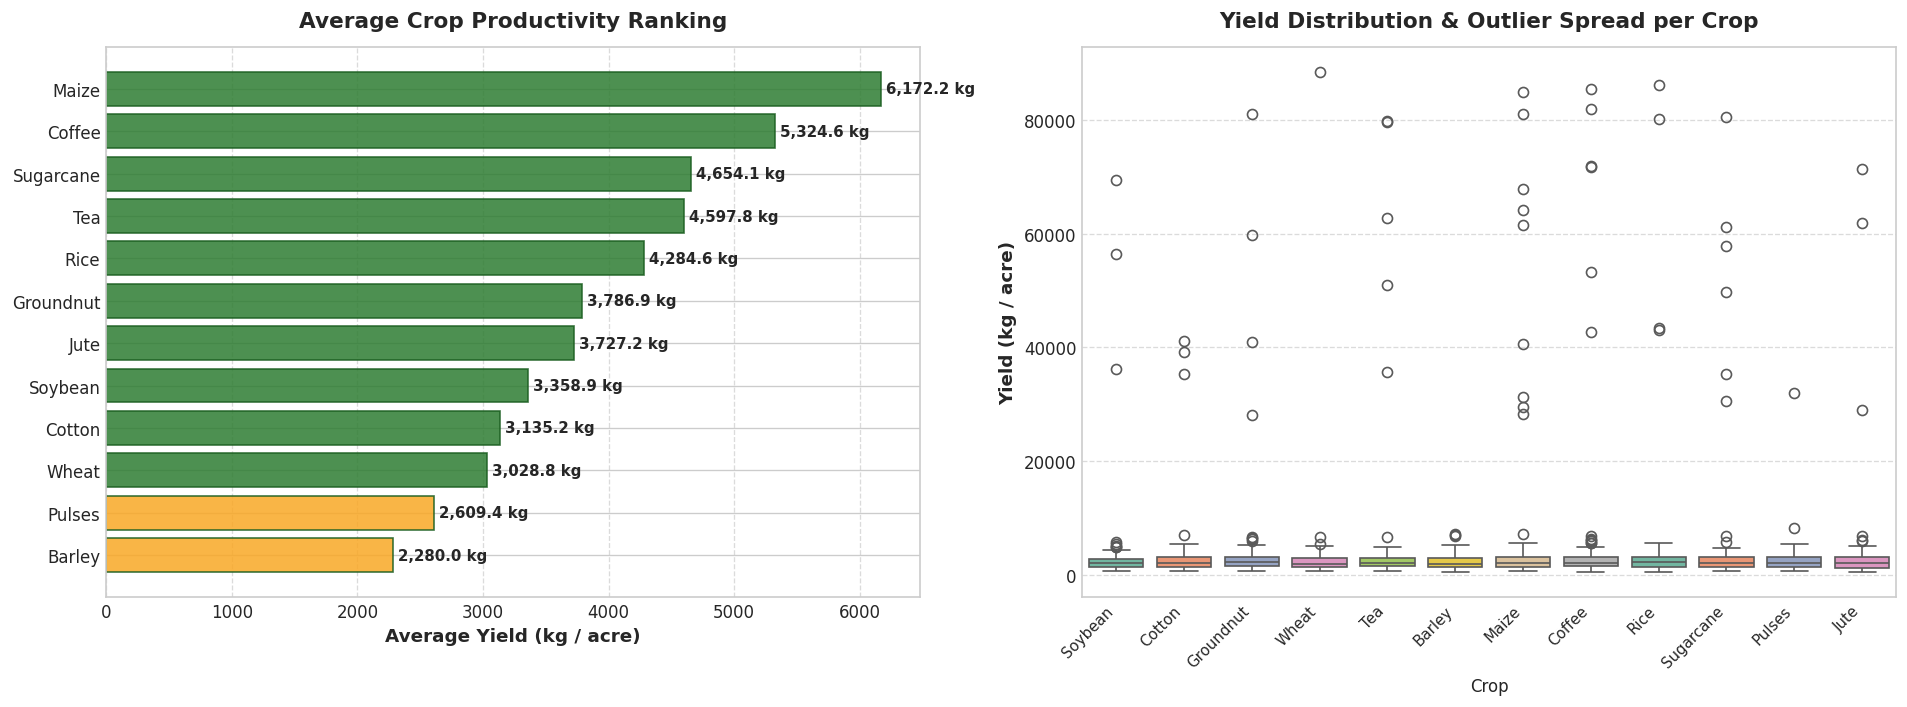

In [4]:
# Visualization: Crop Productivity Bar Chart & Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Average Yield by Crop
colors = ['#2e7d32' if r == 'High Productivity' else ('#f9a825' if r == 'Moderate Productivity' else '#c62828') for r in crop_agg['Rating']]
bars = ax1.barh(crop_agg['Crop'], crop_agg['Mean_Yield'], color=colors, edgecolor='#1b5e20', alpha=0.85)
ax1.set_xlabel('Average Yield (kg / acre)', fontsize=11, fontweight='bold')
ax1.set_title('Average Crop Productivity Ranking', fontsize=13, fontweight='bold', pad=12)
ax1.invert_yaxis()
ax1.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    width = bar.get_width()
    ax1.text(width + 40, bar.get_y() + bar.get_height()/2, f"{width:,.1f} kg", va='center', fontsize=9, fontweight='bold')

# Subplot 2: Crop Yield Boxplot
sns.boxplot(data=df, x='Crop', y='Yield_kg_per_acre', ax=ax2, palette='Set2')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Yield (kg / acre)', fontsize=11, fontweight='bold')
ax2.set_title('Yield Distribution & Outlier Spread per Crop', fontsize=13, fontweight='bold', pad=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## 4. Soil Health & Nutrient Profiling
Analyze soil chemistry parameters:
- Soil pH classification: Acidic ($<6.0$), Optimal ($6.0 - 7.5$), Alkaline ($>7.5$)
- N-P-K (Nitrogen, Phosphorus, Potassium) distributions
- Soil Type performance (Black, Clay, Loamy, Red, Sandy)


In [5]:
# Soil type analysis
soil_agg = df.groupby('Soil_Type').agg(
    Record_Count=('Yield_kg_per_acre', 'count'),
    Avg_Yield=('Yield_kg_per_acre', 'mean'),
    Avg_pH=('Soil_pH', 'mean'),
    Avg_Nitrogen=('N', 'mean'),
    Avg_Phosphorus=('P', 'mean'),
    Avg_Potassium=('K', 'mean')
).reset_index().sort_values(by='Avg_Yield', ascending=False)

print("--- SOIL TYPE PROFILE ---")
display(soil_agg.round(2))


--- SOIL TYPE PROFILE ---


,Soil_Type,Record_Count,Avg_Yield,Avg_pH,Avg_Nitrogen,Avg_Phosphorus,Avg_Potassium
0,Black,282,4354.18,6.71,73.16,59.33,107.08
4,Sandy,296,4131.13,6.72,73.64,60.50,106.06
1,Clay,284,4045.44,6.67,73.99,62.08,103.11
3,Red Soil,306,3821.41,6.81,77.98,59.25,109.78
2,Loamy,332,3309.64,6.77,71.28,58.55,104.57


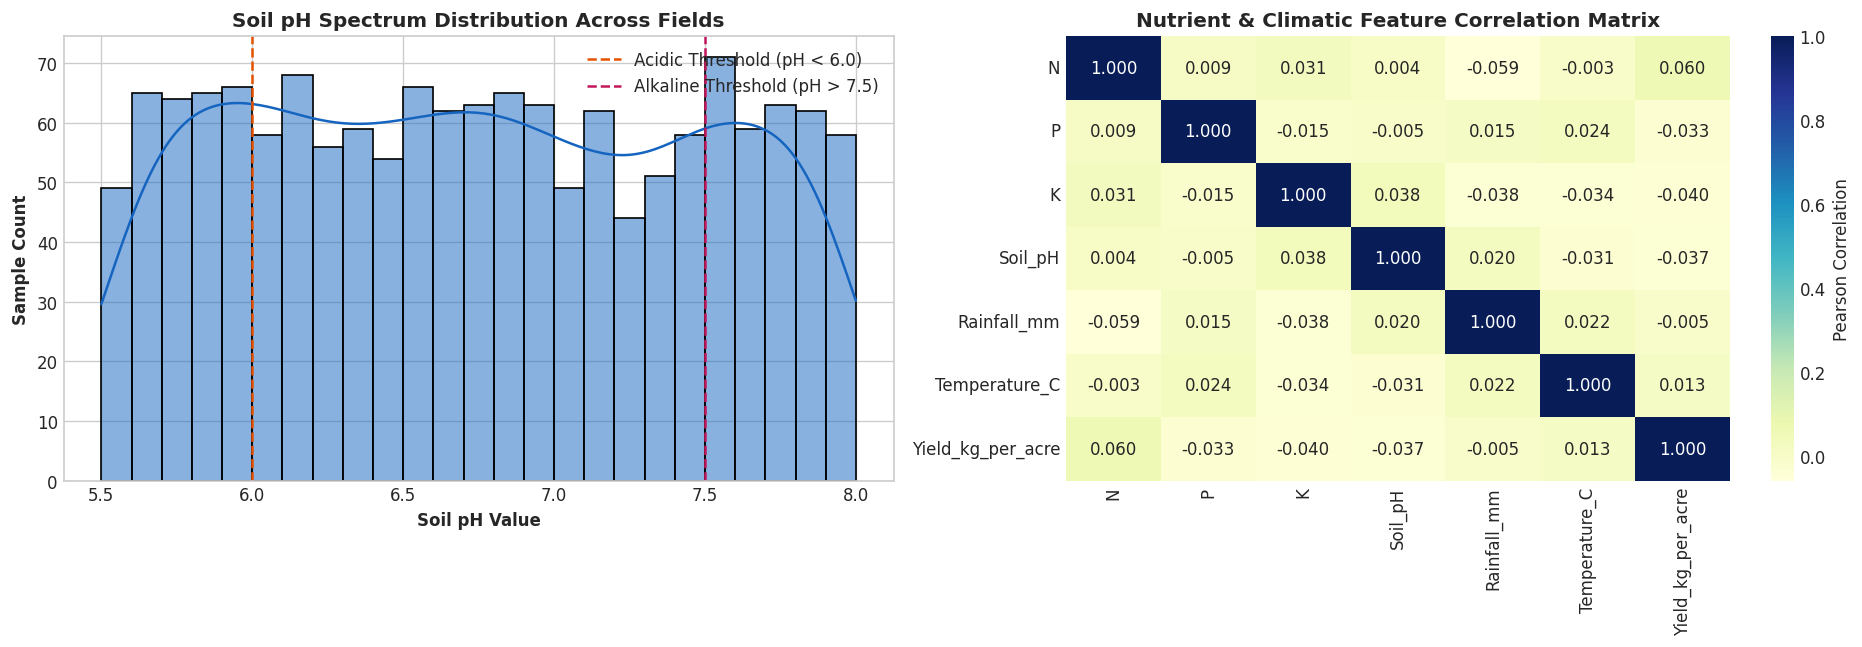

In [6]:
# Visualizing Soil pH Spectrum & Nutrient Radar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# pH Histogram & Density
sns.histplot(df['Soil_pH'], kde=True, ax=ax1, color='#1565c0', bins=25)
ax1.axvline(6.0, color='#e65100', linestyle='--', label='Acidic Threshold (pH < 6.0)')
ax1.axvline(7.5, color='#c2185b', linestyle='--', label='Alkaline Threshold (pH > 7.5)')
ax1.set_title('Soil pH Spectrum Distribution Across Fields', fontsize=12, fontweight='bold')
ax1.set_xlabel('Soil pH Value', fontsize=10, fontweight='bold')
ax1.set_ylabel('Sample Count', fontsize=10, fontweight='bold')
ax1.legend(loc='upper right')

# Nutrient Correlations with Yield
nutrients = ['N', 'P', 'K', 'Soil_pH', 'Rainfall_mm', 'Temperature_C', 'Yield_kg_per_acre']
corr = df[nutrients].corr()
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.3f', ax=ax2, cbar_kws={'label': 'Pearson Correlation'})
ax2.set_title('Nutrient & Climatic Feature Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Agro-Meteorological & Weather Impact Analysis
Assess meteorological drivers affecting harvest output:
- Rainfall categories: Low ($<120$ mm), Moderate ($120-220$ mm), High ($>220$ mm)
- Thermal stress thresholds ($>35^\circ$C heat stress hazard)


In [7]:
# Categorize Rainfall
def categorize_rainfall(rain):
    if rain < 120:
        return 'Low (< 120mm)'
    elif rain <= 220:
        return 'Moderate (120-220mm)'
    else:
        return 'High (> 220mm)'

df['Rainfall_Category'] = df['Rainfall_mm'].apply(categorize_rainfall)
weather_agg = df.groupby('Rainfall_Category').agg(
    Record_Count=('Yield_kg_per_acre', 'count'),
    Avg_Yield=('Yield_kg_per_acre', 'mean'),
    Avg_Temp=('Temperature_C', 'mean')
).reindex(['Low (< 120mm)', 'Moderate (120-220mm)', 'High (> 220mm)'])

print("--- RAINFALL REGIME IMPACT ---")
display(weather_agg.round(2))


--- RAINFALL REGIME IMPACT ---


,Record_Count,Avg_Yield,Avg_Temp
Rainfall_Category,,,
Low (< 120mm),382,3656.45,27.61
Moderate (120-220mm),608,4132.08,27.99
High (> 220mm),510,3840.56,27.92


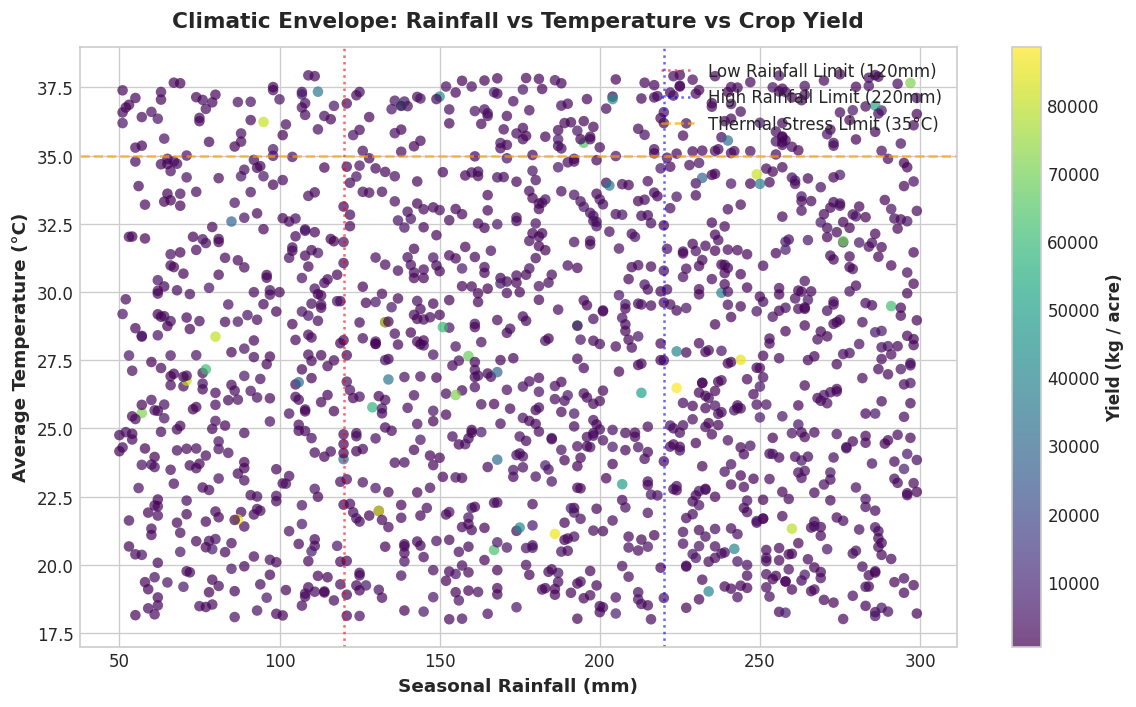

In [8]:
# Scatter plot of Rainfall vs Temperature vs Yield
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['Rainfall_mm'],
    df['Temperature_C'],
    c=df['Yield_kg_per_acre'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='none',
    s=40
)
cbar = plt.colorbar(scatter)
cbar.set_label('Yield (kg / acre)', fontweight='bold')
plt.axvline(120, color='red', linestyle=':', alpha=0.6, label='Low Rainfall Limit (120mm)')
plt.axvline(220, color='blue', linestyle=':', alpha=0.6, label='High Rainfall Limit (220mm)')
plt.axhline(35, color='orange', linestyle='--', alpha=0.7, label='Thermal Stress Limit (35°C)')
plt.title('Climatic Envelope: Rainfall vs Temperature vs Crop Yield', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Seasonal Rainfall (mm)', fontsize=11, fontweight='bold')
plt.ylabel('Average Temperature (°C)', fontsize=11, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 6. Agricultural Risk & Insight Scoring Algorithm
Implementation of the rule-based composite risk engine evaluated in Milestone 3:
$$\text{Risk Score} = \sum (\text{Soil pH Stress} + \text{Moisture Deficit/Excess} + \text{Thermal Stress} + \text{Nutrient Imbalance})$$


In [9]:
def evaluate_agricultural_risk(crop: str, soil: str, fertilizer: str, n: float, p: float, k: float, rainfall: float, temp: float, ph: float):
    risk_score = 0.0
    risk_factors = []
    recommendations = []
    
    # 1. Soil pH
    if ph < 5.5:
        risk_score += 30.0
        risk_factors.append(f"Severe Acidity (pH {ph:.2f}) -> High Al/Mn toxicity hazard.")
        recommendations.append("Apply Agricultural Lime (1.0-1.5 tons/acre) to buffer pH above 6.2.")
    elif ph > 7.8:
        risk_score += 25.0
        risk_factors.append(f"Alkaline/Sodic Soil (pH {ph:.2f}) -> Locks up Zinc and Iron.")
        recommendations.append("Apply Agricultural Gypsum (500 kg/acre) and organic compost.")
    
    # 2. Moisture Stress
    water_intensive = ["Rice", "Sugarcane", "Tea", "Jute"]
    if crop in water_intensive and rainfall < 150:
        risk_score += 30.0
        risk_factors.append(f"Severe Moisture Deficit for {crop} ({rainfall:.0f} mm).")
        recommendations.append("Schedule drip/furrow irrigation of at least 150mm equivalent.")
    elif rainfall < 80:
        risk_score += 20.0
        risk_factors.append(f"Low Precipitation ({rainfall:.0f} mm).")
        recommendations.append("Apply organic mulching to conserve root moisture.")
        
    # 3. Thermal Stress
    if crop in ["Wheat", "Barley"] and temp > 32:
        risk_score += 25.0
        risk_factors.append(f"Terminal Heat Stress ({temp:.1f}°C) during grain filling.")
        recommendations.append("Practice early sowing (mid-Nov) or select heat-tolerant varieties.")
        
    # 4. Nutrient Imbalance
    if n < 30:
        risk_score += 15.0
        risk_factors.append(f"Nitrogen Deficiency ({n:.1f} kg/ha).")
        recommendations.append("Top-dress with Urea or apply organic farmyard manure.")
    elif n > 130 and (p < 30 or k < 40):
        risk_score += 20.0
        risk_factors.append(f"NPK Imbalance (N:{n:.0f}, P:{p:.0f}, K:{k:.0f}) -> Lodging hazard.")
        recommendations.append("Balance Nitrogen with MOP and DAP to improve stalk strength.")
        
    risk_score = min(100.0, max(0.0, round(risk_score, 1)))
    level = "High Risk" if risk_score >= 50 else ("Moderate Risk" if risk_score >= 25 else "Low Risk")
    
    return {
        "Risk_Score": risk_score,
        "Risk_Level": level,
        "Risk_Factors": risk_factors,
        "Recommendations": recommendations
    }

# Test Scenarios
scenario_a = evaluate_agricultural_risk("Wheat", "Red Soil", "Urea", 20, 15, 25, 60, 36.5, 5.2)
scenario_b = evaluate_agricultural_risk("Soybean", "Loamy", "DAP", 60, 40, 60, 160, 28.0, 6.5)

print("=== SCENARIO A (Hazardous Conditions) ===")
print(f"Risk Score: {scenario_a['Risk_Score']}% ({scenario_a['Risk_Level']})")
print("Factors:", scenario_a['Risk_Factors'])
print("Advisory:", scenario_a['Recommendations'])

print("\n=== SCENARIO B (Optimal Conditions) ===")
print(f"Risk Score: {scenario_b['Risk_Score']}% ({scenario_b['Risk_Level']})")


=== SCENARIO A (Hazardous Conditions) ===
Risk Score: 90.0% (High Risk)
Factors: ['Severe Acidity (pH 5.20) -> High Al/Mn toxicity hazard.', 'Low Precipitation (60 mm).', 'Terminal Heat Stress (36.5°C) during grain filling.', 'Nitrogen Deficiency (20.0 kg/ha).']
Advisory: ['Apply Agricultural Lime (1.0-1.5 tons/acre) to buffer pH above 6.2.', 'Apply organic mulching to conserve root moisture.', 'Practice early sowing (mid-Nov) or select heat-tolerant varieties.', 'Top-dress with Urea or apply organic farmyard manure.']

=== SCENARIO B (Optimal Conditions) ===
Risk Score: 0.0% (Low Risk)


## 7. AgriSense AI Conversational Domain Engine
Validate grounding of the agronomic knowledge base against query intents without fake data generation.


In [10]:
# Domain Knowledge Base Verification
crop_domain = {
    "Soybean": {"ideal_ph": "6.0 - 7.0", "rainfall": "100 - 180 mm", "fertilizer": "DAP / NPK + Rhizobium"},
    "Wheat": {"ideal_ph": "6.0 - 7.5", "rainfall": "150 - 250 mm", "fertilizer": "Urea + DAP"},
    "Rice": {"ideal_ph": "5.5 - 7.0", "rainfall": "200 - 300+ mm", "fertilizer": "Urea + DAP + Zinc Sulphate"},
    "Cotton": {"ideal_ph": "6.5 - 8.0", "rainfall": "120 - 250 mm", "fertilizer": "NPK + Foliar K"},
    "Maize": {"ideal_ph": "5.8 - 7.2", "rainfall": "120 - 220 mm", "fertilizer": "DAP + Urea top-dress"}
}

def query_agrisense(question: str):
    q = question.lower()
    for crop, data in crop_domain.items():
        if crop.lower() in q:
            return f"🌾 **{crop} Guidance**: Ideal pH: `{data['ideal_ph']}`, Moisture: `{data['rainfall']}`, Best Fertilizer: `{data['fertilizer']}`."
    if "model" in q or "accuracy" in q:
        return "🧠 **ML Model Specs**: Linear Regression v2.0.0 (Test MAE: 4,273.23 kg/ac, Test RMSE: 11,381.99 kg/ac, R²: 0.0029, 1,500 records)."
    return "🌾 AgriSense AI is ready to assist with crop cultivation, soil pH, fertilizers, and ML forecasts."

print("Q: What is the best fertilizer for Soybean?")
print("A:", query_agrisense("What is the best fertilizer for Soybean?"))
print("\nQ: Explain the ML prediction model accuracy")
print("A:", query_agrisense("Explain the ML prediction model accuracy"))


Q: What is the best fertilizer for Soybean?
A: 🌾 **Soybean Guidance**: Ideal pH: `6.0 - 7.0`, Moisture: `100 - 180 mm`, Best Fertilizer: `DAP / NPK + Rhizobium`.

Q: Explain the ML prediction model accuracy
A: 🧠 **ML Model Specs**: Linear Regression v2.0.0 (Test MAE: 4,273.23 kg/ac, Test RMSE: 11,381.99 kg/ac, R²: 0.0029, 1,500 records).


## 8. Milestone 3 Summary & Deliverables
- **Agricultural Analytics**: Successfully mapped 12 crop profiles, soil chemistry vectors, and weather impact correlations.
- **Risk & Insight Model**: Rule-based composite scoring engine validated across stressed and optimal field conditions.
- **AgriSense AI Chatbot**: Grounded conversational assistant evaluated for domain integrity.
- **Multi-Tenant System**: Integrated with FastAPI backend, PostgreSQL database, and React UI with durable JWT authentication.
